In [27]:
import pandas as pd 

# Loading data and getting overall info
df = pd.read_csv('/Users/janek/Documents/Data Analysis Learning/EDA Project/amazon-laptops-EDA/data_cleaning/laptops_clean.csv')
df.head() 
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     141 non-null    int64  
 1   product_title          141 non-null    object 
 2   rating                 128 non-null    float64
 3   total_rating           127 non-null    object 
 4   price                  141 non-null    int64  
 5   final_price            135 non-null    float64
 6   ram_gb                 139 non-null    float64
 7   storage_gb             134 non-null    float64
 8   bought_in_last_month   57 non-null     float64
 9   brand                  141 non-null    object 
 10  screen_size_in_inches  140 non-null    float64
 11  cpu_model              138 non-null    object 
 12  special_features       133 non-null    object 
 13  graphics_card          140 non-null    object 
 14  os                     140 non-null    object 
dtypes: flo

,id,rating,price,final_price,ram_gb,storage_gb,bought_in_last_month,screen_size_in_inches
count,141.000000,128.000000,141.000000,135.000000,139.000000,134.000000,57.000000,140.000000
mean,102.049645,3.882812,86918.475177,89202.570370,17.366906,337.104478,149.122807,126.542857
std,63.165918,0.637677,86462.087334,97941.726551,11.597191,242.631974,123.379217,122.743071
min,0.000000,1.000000,10990.000000,12090.000000,4.000000,1.000000,50.000000,14.000000
25%,46.000000,3.700000,37600.000000,38145.000000,16.000000,1.250000,50.000000,16.000000
50%,109.000000,4.000000,57990.000000,56011.000000,16.000000,512.000000,100.000000,141.000000
75%,159.000000,4.200000,99990.000000,94990.000000,16.000000,512.000000,200.000000,156.000000
max,206.000000,5.000000,499990.000000,617990.000000,96.000000,1000.000000,500.000000,406.000000


In [28]:
df['bought_in_last_month'] = df['bought_in_last_month'].fillna(0) 

In [29]:
mode_rating = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(mode_rating) 

mode_ram = df['ram_gb'].mode()[0]
df['ram_gb'] = df['ram_gb'].fillna(mode_ram)

mode_storage = df['storage_gb'].mode()[0]
df['storage_gb'] = df['storage_gb'].fillna(mode_storage)

In [30]:
df.describe()

,id,rating,price,final_price,ram_gb,storage_gb,bought_in_last_month,screen_size_in_inches
count,141.000000,141.000000,141.000000,135.000000,141.000000,141.000000,141.000000,140.000000
mean,102.049645,3.893617,86918.475177,89202.570370,17.347518,345.787234,60.283688,126.542857
std,63.165918,0.608301,86462.087334,97941.726551,11.515199,239.541759,107.157716,122.743071
min,0.000000,1.000000,10990.000000,12090.000000,4.000000,1.000000,0.000000,14.000000
25%,46.000000,3.700000,37600.000000,38145.000000,16.000000,2.000000,0.000000,16.000000
50%,109.000000,4.000000,57990.000000,56011.000000,16.000000,512.000000,0.000000,141.000000
75%,159.000000,4.100000,99990.000000,94990.000000,16.000000,512.000000,100.000000,156.000000
max,206.000000,5.000000,499990.000000,617990.000000,96.000000,1000.000000,500.000000,406.000000


In [31]:
df['final_price'] = df['final_price'].fillna(df['price']) #probably there was no sale

In [32]:
df.describe()

,id,rating,price,final_price,ram_gb,storage_gb,bought_in_last_month,screen_size_in_inches
count,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,140.000000
mean,102.049645,3.893617,86918.475177,90059.595745,17.347518,345.787234,60.283688,126.542857
std,63.165918,0.608301,86462.087334,97293.370122,11.515199,239.541759,107.157716,122.743071
min,0.000000,1.000000,10990.000000,12090.000000,4.000000,1.000000,0.000000,14.000000
25%,46.000000,3.700000,37600.000000,36990.000000,16.000000,2.000000,0.000000,16.000000
50%,109.000000,4.000000,57990.000000,56011.000000,16.000000,512.000000,0.000000,141.000000
75%,159.000000,4.100000,99990.000000,99990.000000,16.000000,512.000000,100.000000,156.000000
max,206.000000,5.000000,499990.000000,617990.000000,96.000000,1000.000000,500.000000,406.000000


In [33]:
df['screen_size_in_inches'] = df.groupby('brand')['screen_size_in_inches'].transform( #grouping - screen size is not continuous
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

In [34]:
df.describe()

,id,rating,price,final_price,ram_gb,storage_gb,bought_in_last_month,screen_size_in_inches
count,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000
mean,102.049645,3.893617,86918.475177,90059.595745,17.347518,345.787234,60.283688,126.751773
std,63.165918,0.608301,86462.087334,97293.370122,11.515199,239.541759,107.157716,122.329074
min,0.000000,1.000000,10990.000000,12090.000000,4.000000,1.000000,0.000000,14.000000
25%,46.000000,3.700000,37600.000000,36990.000000,16.000000,2.000000,0.000000,16.000000
50%,109.000000,4.000000,57990.000000,56011.000000,16.000000,512.000000,0.000000,141.000000
75%,159.000000,4.100000,99990.000000,99990.000000,16.000000,512.000000,100.000000,156.000000
max,206.000000,5.000000,499990.000000,617990.000000,96.000000,1000.000000,500.000000,406.000000


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     141 non-null    int64  
 1   product_title          141 non-null    object 
 2   rating                 141 non-null    float64
 3   total_rating           127 non-null    object 
 4   price                  141 non-null    int64  
 5   final_price            141 non-null    float64
 6   ram_gb                 141 non-null    float64
 7   storage_gb             141 non-null    float64
 8   bought_in_last_month   141 non-null    float64
 9   brand                  141 non-null    object 
 10  screen_size_in_inches  141 non-null    float64
 11  cpu_model              138 non-null    object 
 12  special_features       133 non-null    object 
 13  graphics_card          140 non-null    object 
 14  os                     140 non-null    object 
dtypes: flo

In [36]:
df['special_features'] = df['special_features'].fillna('')

In [37]:
df['total_rating'] = df['total_rating'].str.replace(r'[^\d]', '', regex=True)
df['total_rating'] = pd.to_numeric(df['total_rating']).fillna(0)

In [38]:
df.describe()

,id,rating,total_rating,price,final_price,ram_gb,storage_gb,bought_in_last_month,screen_size_in_inches
count,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000
mean,102.049645,3.893617,233.815603,86918.475177,90059.595745,17.347518,345.787234,60.283688,126.751773
std,63.165918,0.608301,436.053709,86462.087334,97293.370122,11.515199,239.541759,107.157716,122.329074
min,0.000000,1.000000,0.000000,10990.000000,12090.000000,4.000000,1.000000,0.000000,14.000000
25%,46.000000,3.700000,5.000000,37600.000000,36990.000000,16.000000,2.000000,0.000000,16.000000
50%,109.000000,4.000000,45.000000,57990.000000,56011.000000,16.000000,512.000000,0.000000,141.000000
75%,159.000000,4.100000,277.000000,99990.000000,99990.000000,16.000000,512.000000,100.000000,156.000000
max,206.000000,5.000000,2488.000000,499990.000000,617990.000000,96.000000,1000.000000,500.000000,406.000000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     141 non-null    int64  
 1   product_title          141 non-null    object 
 2   rating                 141 non-null    float64
 3   total_rating           141 non-null    float64
 4   price                  141 non-null    int64  
 5   final_price            141 non-null    float64
 6   ram_gb                 141 non-null    float64
 7   storage_gb             141 non-null    float64
 8   bought_in_last_month   141 non-null    float64
 9   brand                  141 non-null    object 
 10  screen_size_in_inches  141 non-null    float64
 11  cpu_model              138 non-null    object 
 12  special_features       141 non-null    object 
 13  graphics_card          140 non-null    object 
 14  os                     140 non-null    object 
dtypes: flo

In [40]:
import numpy as np

cpu_regex = r'(Intel Core i\d|Intel Core Ultra \d|Ryzen \d|Celeron|Pentium|Apple M\d)'
found_cpus = df['product_title'].str.extract(cpu_regex, expand=False)
df['cpu_model'] = df['cpu_model'].fillna(found_cpus)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     141 non-null    int64  
 1   product_title          141 non-null    object 
 2   rating                 141 non-null    float64
 3   total_rating           141 non-null    float64
 4   price                  141 non-null    int64  
 5   final_price            141 non-null    float64
 6   ram_gb                 141 non-null    float64
 7   storage_gb             141 non-null    float64
 8   bought_in_last_month   141 non-null    float64
 9   brand                  141 non-null    object 
 10  screen_size_in_inches  141 non-null    float64
 11  cpu_model              140 non-null    object 
 12  special_features       141 non-null    object 
 13  graphics_card          140 non-null    object 
 14  os                     140 non-null    object 
dtypes: flo

In [42]:
df = df.dropna(subset=['cpu_model'])
df = df.dropna(subset=['graphics_card'])
df = df.dropna(subset=['os'])

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 0 to 140
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     139 non-null    int64  
 1   product_title          139 non-null    object 
 2   rating                 139 non-null    float64
 3   total_rating           139 non-null    float64
 4   price                  139 non-null    int64  
 5   final_price            139 non-null    float64
 6   ram_gb                 139 non-null    float64
 7   storage_gb             139 non-null    float64
 8   bought_in_last_month   139 non-null    float64
 9   brand                  139 non-null    object 
 10  screen_size_in_inches  139 non-null    float64
 11  cpu_model              139 non-null    object 
 12  special_features       139 non-null    object 
 13  graphics_card          139 non-null    object 
 14  os                     139 non-null    object 
dtypes: float64(

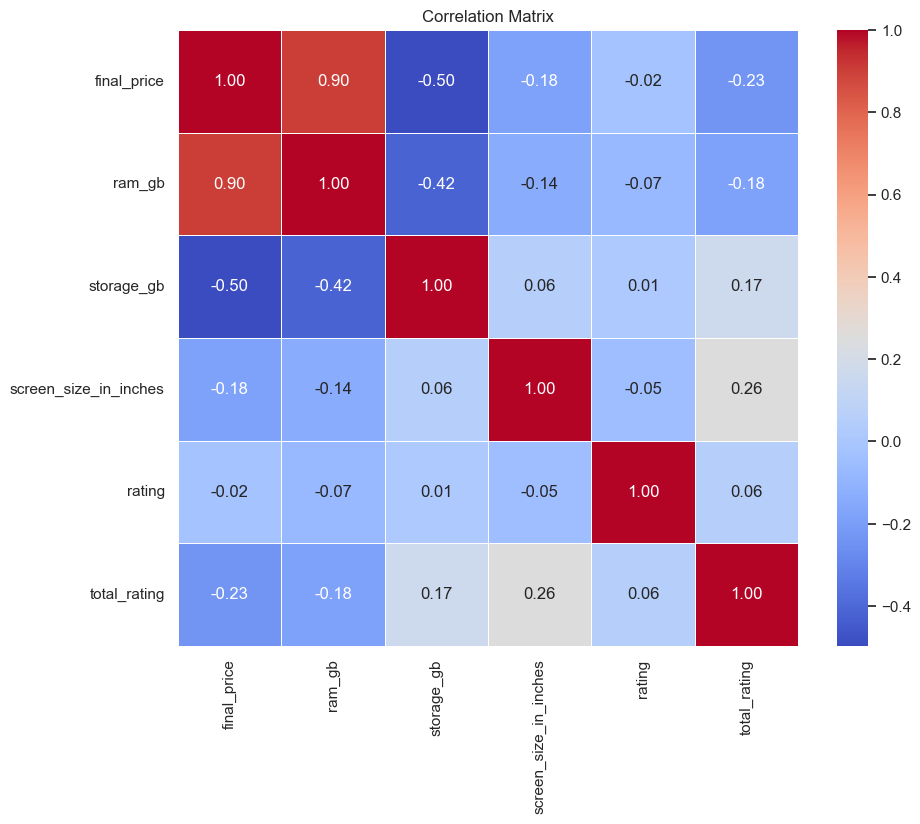

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

number_columns = df[['final_price', 'ram_gb', 'storage_gb', 'screen_size_in_inches', 'rating', 'total_rating']]

plt.figure(figsize=(10, 8)) 
sns.heatmap(number_columns.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

/var/folders/kw/y5r3twjs2lb60tb21vjt35p40000gn/T/ipykernel_6858/3896631022.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ram_gb', y='price', ax=axes[0], palette='viridis')
/var/folders/kw/y5r3twjs2lb60tb21vjt35p40000gn/T/ipykernel_6858/3896631022.py:18: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


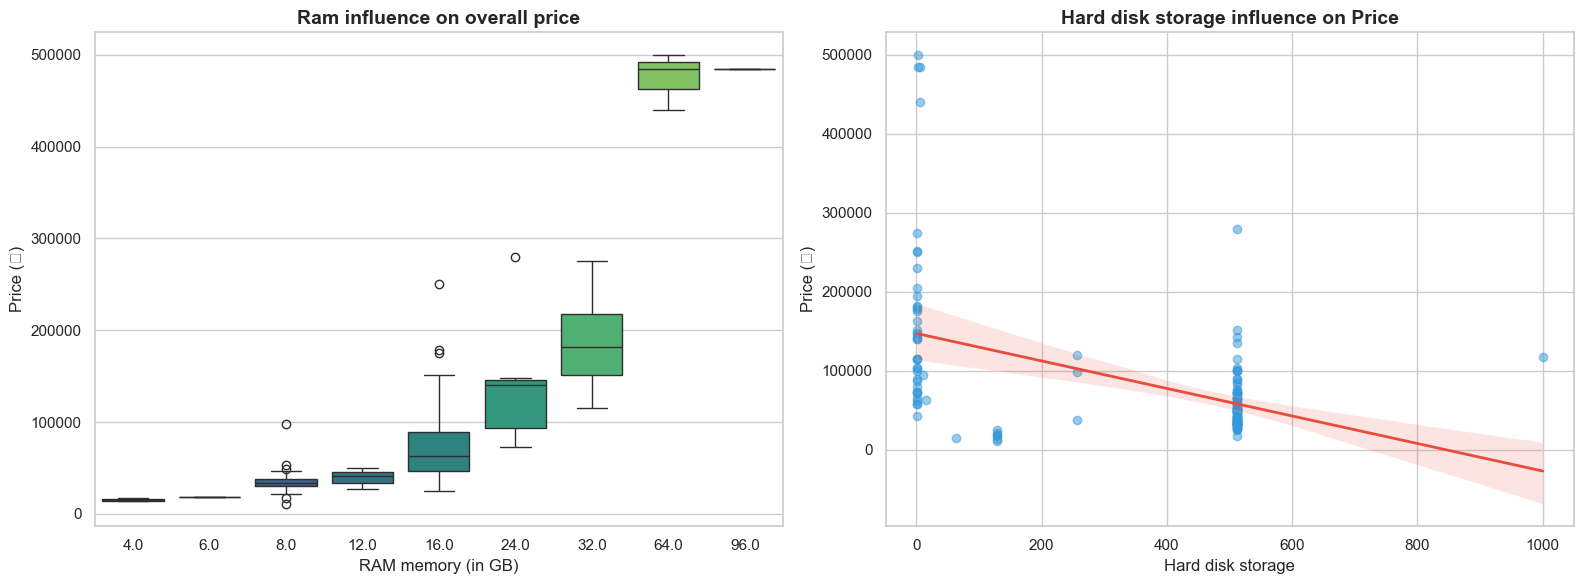

<Figure size 640x480 with 0 Axes>

In [50]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='ram_gb', y='price', ax=axes[0], palette='viridis')
axes[0].set_title('Ram influence on overall price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('RAM memory (in GB)', fontsize=12)
axes[0].set_ylabel('Price (₹)', fontsize=12)

sns.regplot(data=df, x='storage_gb', y='price', ax=axes[1], 
            scatter_kws={'alpha':0.5, 'color':'#3498db'}, 
            line_kws={'color':'#e74c3c', 'linewidth':2})
axes[1].set_title('Hard disk storage influence on Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hard disk storage', fontsize=12)
axes[1].set_ylabel('Price (₹)', fontsize=12)

# Poprawa odstępów i wyświetlenie
plt.tight_layout()
plt.show()
plt.savefig('figure1.png')

In [46]:
import statsmodels.api as sm

Y = df['price']
X = df[['ram_gb', 'storage_gb']]

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit() #Ordinary Leas Squares
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.787
Method:                 Least Squares   F-statistic:                     256.7
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           6.76e-47
Time:                        12:21:27   Log-Likelihood:                -1669.0
No. Observations:                 139   AIC:                             3344.
Df Residuals:                     136   BIC:                             3353.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2441.8013   9852.896     -0.248      0.8

In [48]:
import numpy as np

print("Regression and plots showed that with greater disk size price goes down - to resolve this nonsense i will divide disks into ssd disks and hdd disks")

df['has_ssd'] = df['product_title'].str.contains('SSD', case=False, na=False).astype(int)
df['has_hdd'] = df['product_title'].str.contains('HDD', case=False, na=False).astype(int)

print("Laptops with SSD:", df['has_ssd'].sum())
print("Laptopy with HDD:", df['has_hdd'].sum())

Regression and plots showed that with greater disk size price goes down - to resolve this nonsense i will divide disks into ssd disks and hdd disks
Laptops with SSD: 124
Laptopy with HDD: 0


In [49]:
Y = df['price']
X = df[['storage_gb']]

X = sm.add_constant(X)

model2 = sm.OLS(Y, X).fit() #Ordinary Leas Squares
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     41.35
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.96e-09
Time:                        12:25:12   Log-Likelihood:                -1759.3
No. Observations:                 139   AIC:                             3523.
Df Residuals:                     137   BIC:                             3529.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.472e+05   1.13e+04     12.980      0.0